In [ ]:
# Deployed app will run on local host -- streamlit run app.py

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("customer_churn.csv")
df

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,2.0,30.0,Female,39.0,14.0,5.0,18.0,Standard,Annual,932.00,17.0,1.0
1,3.0,65.0,Female,49.0,1.0,10.0,8.0,Basic,Monthly,557.00,6.0,1.0
2,4.0,55.0,Female,14.0,4.0,6.0,18.0,Basic,Quarterly,185.00,3.0,1.0
3,5.0,58.0,Male,38.0,21.0,7.0,7.0,Standard,Monthly,396.00,29.0,1.0
4,6.0,23.0,Male,32.0,20.0,5.0,8.0,Basic,Monthly,617.00,20.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...
440828,449995.0,42.0,Male,54.0,15.0,1.0,3.0,Premium,Annual,716.38,8.0,0.0
440829,449996.0,25.0,Female,8.0,13.0,1.0,20.0,Premium,Annual,745.38,2.0,0.0
440830,449997.0,26.0,Male,35.0,27.0,1.0,5.0,Standard,Quarterly,977.31,9.0,0.0
440831,449998.0,28.0,Male,55.0,14.0,2.0,0.0,Standard,Quarterly,602.55,2.0,0.0


In [3]:
df.shape #no. of rows and colunms

(440833, 12)

In [4]:
df.info() #basic info

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440833 entries, 0 to 440832
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   CustomerID         440832 non-null  float64
 1   Age                440832 non-null  float64
 2   Gender             440832 non-null  object 
 3   Tenure             440832 non-null  float64
 4   Usage Frequency    440832 non-null  float64
 5   Support Calls      440832 non-null  float64
 6   Payment Delay      440832 non-null  float64
 7   Subscription Type  440832 non-null  object 
 8   Contract Length    440832 non-null  object 
 9   Total Spend        440832 non-null  float64
 10  Last Interaction   440832 non-null  float64
 11  Churn              440832 non-null  float64
dtypes: float64(9), object(3)
memory usage: 40.4+ MB


In [5]:
df.describe() #basic stats

,CustomerID,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction,Churn
count,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000
mean,225398.667955,39.373153,31.256336,15.807494,3.604437,12.965722,631.616223,14.480868,0.567107
std,129531.918550,12.442369,17.255727,8.586242,3.070218,8.258063,240.803001,8.596208,0.495477
min,2.000000,18.000000,1.000000,1.000000,0.000000,0.000000,100.000000,1.000000,0.000000
25%,113621.750000,29.000000,16.000000,9.000000,1.000000,6.000000,480.000000,7.000000,0.000000
50%,226125.500000,39.000000,32.000000,16.000000,3.000000,12.000000,661.000000,14.000000,1.000000
75%,337739.250000,48.000000,46.000000,23.000000,6.000000,19.000000,830.000000,22.000000,1.000000
max,449999.000000,65.000000,60.000000,30.000000,10.000000,30.000000,1000.000000,30.000000,1.000000


In [6]:
df.drop('CustomerID',axis=1,inplace=True) #dropping id column as its of no use in training 

In [7]:
df.head()

,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,30.0,Female,39.0,14.0,5.0,18.0,Standard,Annual,932.0,17.0,1.0
1,65.0,Female,49.0,1.0,10.0,8.0,Basic,Monthly,557.0,6.0,1.0
2,55.0,Female,14.0,4.0,6.0,18.0,Basic,Quarterly,185.0,3.0,1.0
3,58.0,Male,38.0,21.0,7.0,7.0,Standard,Monthly,396.0,29.0,1.0
4,23.0,Male,32.0,20.0,5.0,8.0,Basic,Monthly,617.0,20.0,1.0


In [8]:
df.dtypes

Age                  float64
Gender                object
Tenure               float64
Usage Frequency      float64
Support Calls        float64
Payment Delay        float64
Subscription Type     object
Contract Length       object
Total Spend          float64
Last Interaction     float64
Churn                float64
dtype: object

In [9]:
df.isnull().sum()

Age                  1
Gender               1
Tenure               1
Usage Frequency      1
Support Calls        1
Payment Delay        1
Subscription Type    1
Contract Length      1
Total Spend          1
Last Interaction     1
Churn                1
dtype: int64

In [10]:
df[df['Churn'].isnull()]

,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
199295,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [11]:
df = df.dropna()
df

,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,30.0,Female,39.0,14.0,5.0,18.0,Standard,Annual,932.00,17.0,1.0
1,65.0,Female,49.0,1.0,10.0,8.0,Basic,Monthly,557.00,6.0,1.0
2,55.0,Female,14.0,4.0,6.0,18.0,Basic,Quarterly,185.00,3.0,1.0
3,58.0,Male,38.0,21.0,7.0,7.0,Standard,Monthly,396.00,29.0,1.0
4,23.0,Male,32.0,20.0,5.0,8.0,Basic,Monthly,617.00,20.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...
440828,42.0,Male,54.0,15.0,1.0,3.0,Premium,Annual,716.38,8.0,0.0
440829,25.0,Female,8.0,13.0,1.0,20.0,Premium,Annual,745.38,2.0,0.0
440830,26.0,Male,35.0,27.0,1.0,5.0,Standard,Quarterly,977.31,9.0,0.0
440831,28.0,Male,55.0,14.0,2.0,0.0,Standard,Quarterly,602.55,2.0,0.0


In [12]:
hist_col=['Age','Tenure','Usage Frequency','Support Calls','Payment Delay','Total Spend','Last Interaction']
hist_col

['Age',
 'Tenure',
 'Usage Frequency',
 'Support Calls',
 'Payment Delay',
 'Total Spend',
 'Last Interaction']

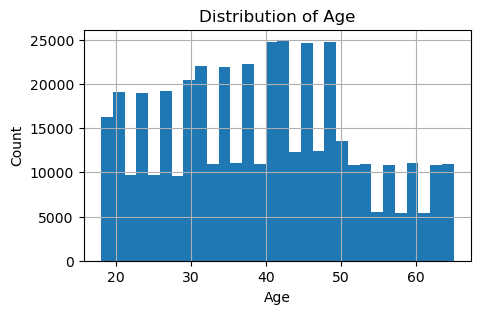

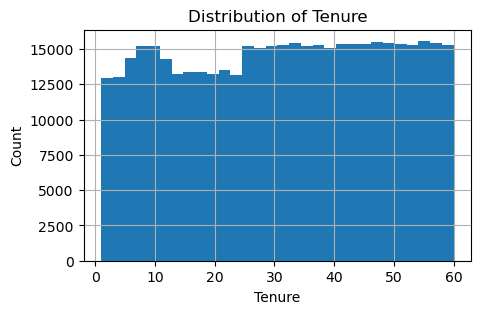

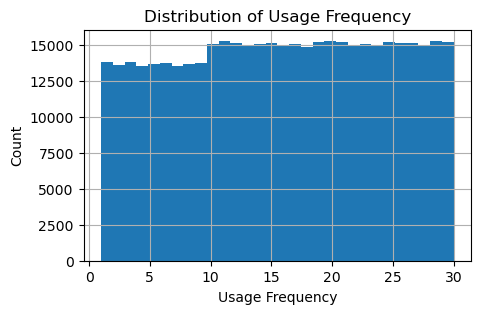

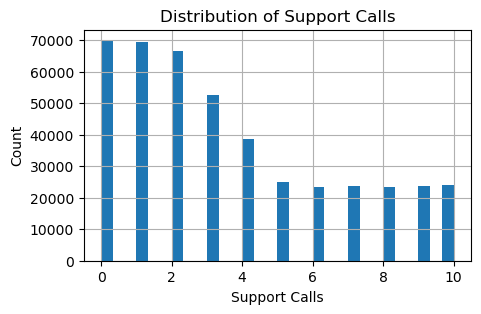

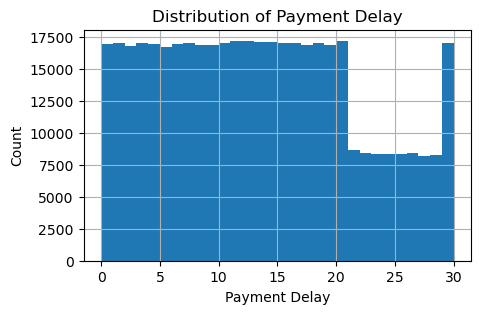

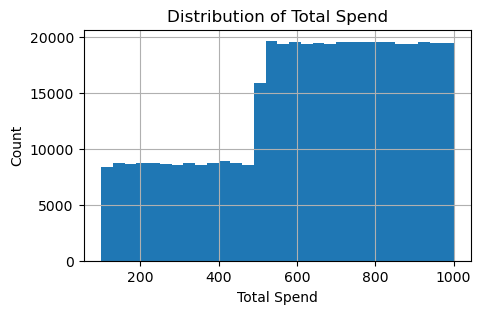

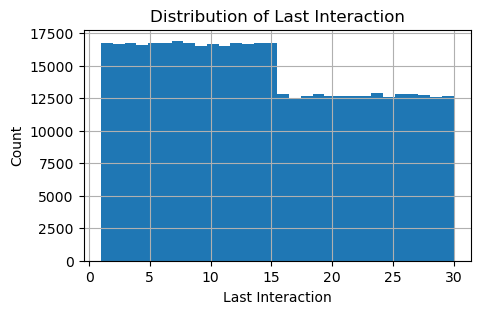

In [13]:
for col in hist_col:
    plt.figure(figsize=(5,3))
    df[col].hist(bins=30)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()

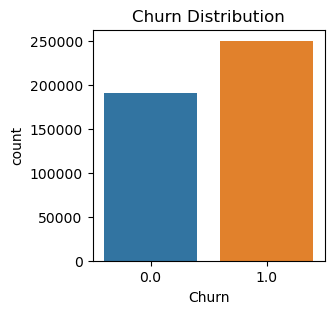

In [14]:
plt.figure(figsize=(3,3))
sns.countplot(x='Churn',data=df)
plt.title('Churn Distribution')
plt.show()

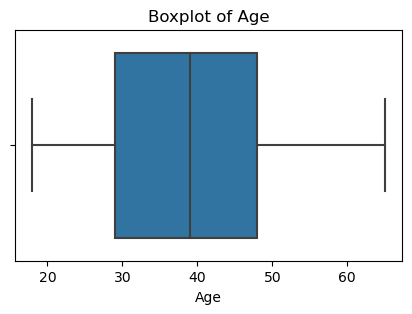

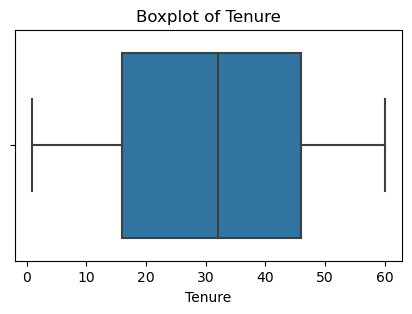

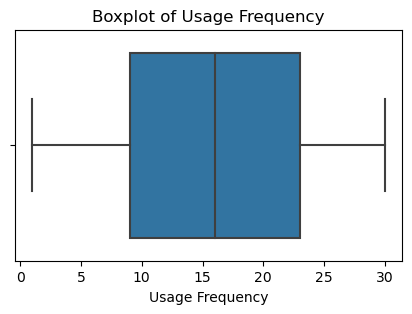

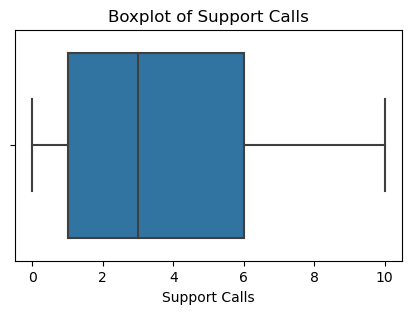

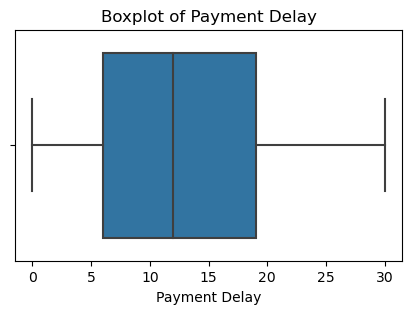

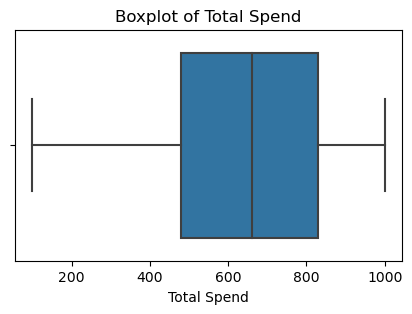

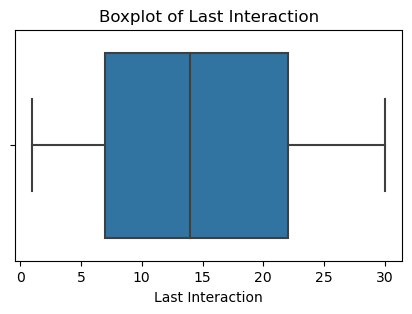

In [15]:
for col in hist_col:
    plt.figure(figsize=(5,3))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

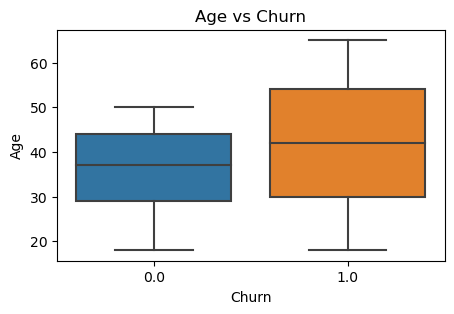

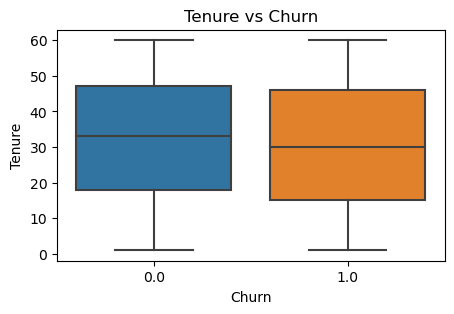

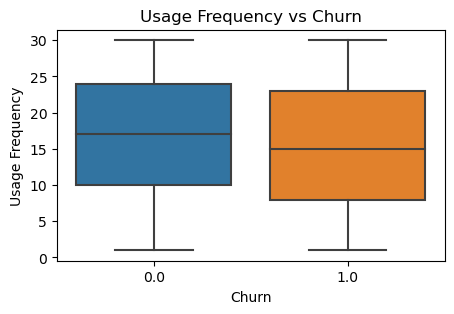

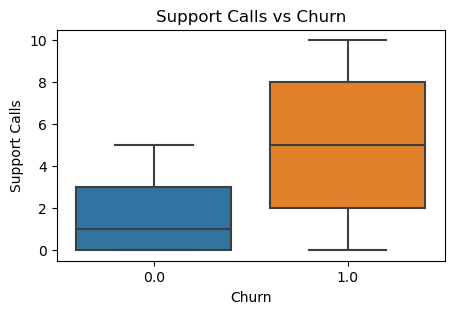

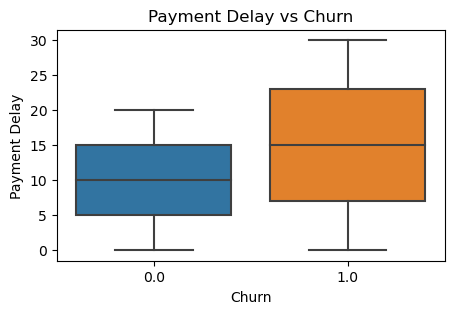

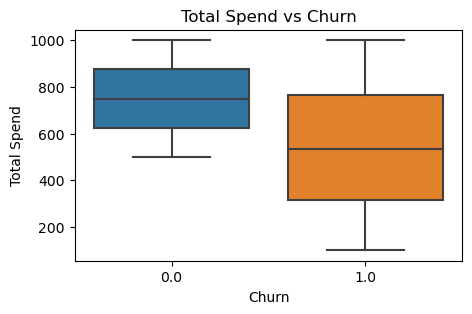

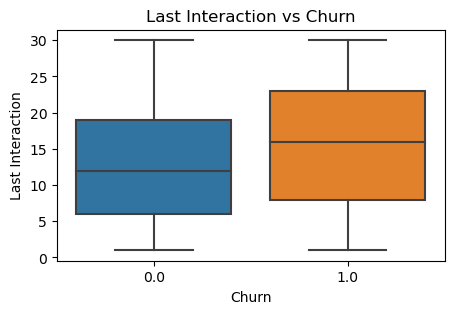

In [16]:
#cols vs churn
  
for col in hist_col:
    plt.figure(figsize=(5,3))
    sns.boxplot(x='Churn',y=col,data=df)
    plt.title(f'{col} vs Churn')
    plt.show()

In [17]:
df.groupby('Churn')['Age'].describe()

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
0.0,190833.0,36.262973,9.203910,18.0,29.0,37.0,44.0,50.0
1.0,249999.0,41.747263,13.975085,18.0,30.0,42.0,54.0,65.0


In [18]:
#for age vs churn :
##the median age of churn1[left] (42) is higher than the churn0[stayed]
##this implies that old customers churned more [but given box overlaps a lot so age is not a sole predictor]

In [19]:
df.groupby('Churn')['Tenure'].describe()

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
0.0,190833.0,32.281754,17.089172,1.0,18.0,33.0,47.0,60.0
1.0,249999.0,30.473598,17.341065,1.0,15.0,30.0,46.0,60.0


In [20]:
#for tenure vs churn
##mean for churn0[stayed] vs churn1[left] is slightly higher
##the difference tells that higher tenure leads to less churning of customers
##churned customers had the lower median tenure(30) i.e.,newer customers more likely discontinued services

In [21]:
df.groupby('Churn')['Usage Frequency'].describe()

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
0.0,190833.0,16.260552,8.446843,1.0,10.0,17.0,24.0,30.0
1.0,249999.0,15.461658,8.675252,1.0,8.0,15.0,23.0,30.0


In [22]:
#for usage freq vs churn
##median for churn0[stayed] customers[18]is slightly higher than that of churn1[left] customers[15]
##that implies usage freq is inversly proportional to churn more usage less churn and vice-versa

In [23]:
df.groupby('Churn')['Support Calls'].describe()

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
0.0,190833.0,1.586418,1.289975,0.0,0.0,1.0,3.0,5.0
1.0,249999.0,5.144861,3.141639,0.0,2.0,5.0,8.0,10.0


In [24]:
#for Support calls vs churn
##the avg for both differ more i.e. the customers who support calls more are more likely to churn as they make calls for complaints
##this strongly predicts churn

In [25]:
df.groupby('Churn')['Payment Delay'].describe()

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
0.0,190833.0,10.015500,6.056744,0.0,5.0,10.0,15.0,20.0
1.0,249999.0,15.217729,8.974081,0.0,7.0,15.0,23.0,30.0


In [26]:
#for payment delay vs churn
##late payers median(17) is higher than early payers median(10) i.e., late payers tend to churn more
##the more payment delays the more churn happens
##this is a strong predictor

In [27]:
df.groupby('Churn')['Total Spend'].describe()

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
0.0,190833.0,749.953111,144.222792,500.0,625.3,749.98,874.74,1000.0
1.0,249999.0,541.285528,259.850723,100.0,316.0,534.00,767.00,1000.0


In [28]:
#for total spend vs churn
##median for total spend for churn0[stayed] is very high than curn1[left] customers
##this implies customers who spend more stays more 

In [29]:
df.groupby('Churn')['Last Interaction'].describe()

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
0.0,190833.0,13.008804,8.291378,1.0,6.0,12.0,19.0,30.0
1.0,249999.0,15.604546,8.654930,1.0,8.0,16.0,23.0,30.0


In [30]:
#for last interactoin vs churn
##median for churn0[stayed][12] customers is lesser than median for churn1[left][16] i.e., longer inactivity leads in churning
##Inactivity is associated with churn.

In [31]:
df.columns

Index(['Age', 'Gender', 'Tenure', 'Usage Frequency', 'Support Calls',
       'Payment Delay', 'Subscription Type', 'Contract Length', 'Total Spend',
       'Last Interaction', 'Churn'],
      dtype='object')

In [32]:
cat_col=['Gender','Contract Length','Subscription Type']
cat_col

['Gender', 'Contract Length', 'Subscription Type']

In [33]:
#count of each value in categorical column

In [34]:
for cat in cat_col:
    print(f"\n===== {cat} =====")
    display(df[cat].value_counts())


===== Gender =====


Gender
Male      250252
Female    190580
Name: count, dtype: int64


===== Contract Length =====


Contract Length
Annual       177198
Quarterly    176530
Monthly       87104
Name: count, dtype: int64


===== Subscription Type =====


Subscription Type
Standard    149128
Premium     148678
Basic       143026
Name: count, dtype: int64

In [35]:
#percentage tab for each categories

In [36]:
for c in cat_col:
    print(f'\n~~~~{c}~~~~')
    print(pd.crosstab(df[c],df['Churn'],normalize='index')*100)


~~~~Gender~~~~
Churn         0.0        1.0
Gender                      
Female  33.330885  66.669115
Male    50.873120  49.126880

~~~~Contract Length~~~~
Churn                  0.0         1.0
Contract Length                       
Annual           53.923859   46.076141
Monthly           0.000000  100.000000
Quarterly        53.974395   46.025605

~~~~Subscription Type~~~~
Churn                    0.0        1.0
Subscription Type                      
Basic              41.821767  58.178233
Premium            44.058300  55.941700
Standard           43.930047  56.069953


In [37]:
#gender vs churn
##Female customers exhibited a significantly higher churn rate (66.7%) compared to male customers (49.1%), suggesting gender may be an important predictor of churn

In [38]:
#contract length vs churn
##monthly subscribers has a rate of 100% churn i.e., a very strong relationship between contract duration and churning of customers

In [39]:
#subscription type vs churn
##basically almost same not a very strong predictor

In [40]:
#Encoding
df=pd.get_dummies(df,columns=['Gender','Contract Length','Subscription Type'],drop_first=True)
df

,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction,Churn,Gender_Male,Contract Length_Monthly,Contract Length_Quarterly,Subscription Type_Premium,Subscription Type_Standard
0,30.0,39.0,14.0,5.0,18.0,932.00,17.0,1.0,False,False,False,False,True
1,65.0,49.0,1.0,10.0,8.0,557.00,6.0,1.0,False,True,False,False,False
2,55.0,14.0,4.0,6.0,18.0,185.00,3.0,1.0,False,False,True,False,False
3,58.0,38.0,21.0,7.0,7.0,396.00,29.0,1.0,True,True,False,False,True
4,23.0,32.0,20.0,5.0,8.0,617.00,20.0,1.0,True,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
440828,42.0,54.0,15.0,1.0,3.0,716.38,8.0,0.0,True,False,False,True,False
440829,25.0,8.0,13.0,1.0,20.0,745.38,2.0,0.0,False,False,False,True,False
440830,26.0,35.0,27.0,1.0,5.0,977.31,9.0,0.0,True,False,True,False,True
440831,28.0,55.0,14.0,2.0,0.0,602.55,2.0,0.0,True,False,True,False,True


In [41]:
df.dtypes

Age                           float64
Tenure                        float64
Usage Frequency               float64
Support Calls                 float64
Payment Delay                 float64
Total Spend                   float64
Last Interaction              float64
Churn                         float64
Gender_Male                      bool
Contract Length_Monthly          bool
Contract Length_Quarterly        bool
Subscription Type_Premium        bool
Subscription Type_Standard       bool
dtype: object

In [42]:
bool_cols = df.select_dtypes(include='bool').columns
df[bool_cols] = df[bool_cols].astype(int)

In [43]:
df.head(2)

,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction,Churn,Gender_Male,Contract Length_Monthly,Contract Length_Quarterly,Subscription Type_Premium,Subscription Type_Standard
0,30.0,39.0,14.0,5.0,18.0,932.0,17.0,1.0,0,0,0,0,1
1,65.0,49.0,1.0,10.0,8.0,557.0,6.0,1.0,0,1,0,0,0


In [44]:
#correlation with churn

In [45]:
df.corr()['Churn'].sort_values(ascending=False)

Churn                         1.000000
Support Calls                 0.574267
Contract Length_Monthly       0.433553
Payment Delay                 0.312129
Age                           0.218394
Last Interaction              0.149616
Subscription Type_Standard   -0.009247
Subscription Type_Premium    -0.011072
Usage Frequency              -0.046101
Tenure                       -0.051919
Gender_Male                  -0.175395
Contract Length_Quarterly    -0.176244
Total Spend                  -0.429355
Name: Churn, dtype: float64

In [46]:
#Correlation heatmap

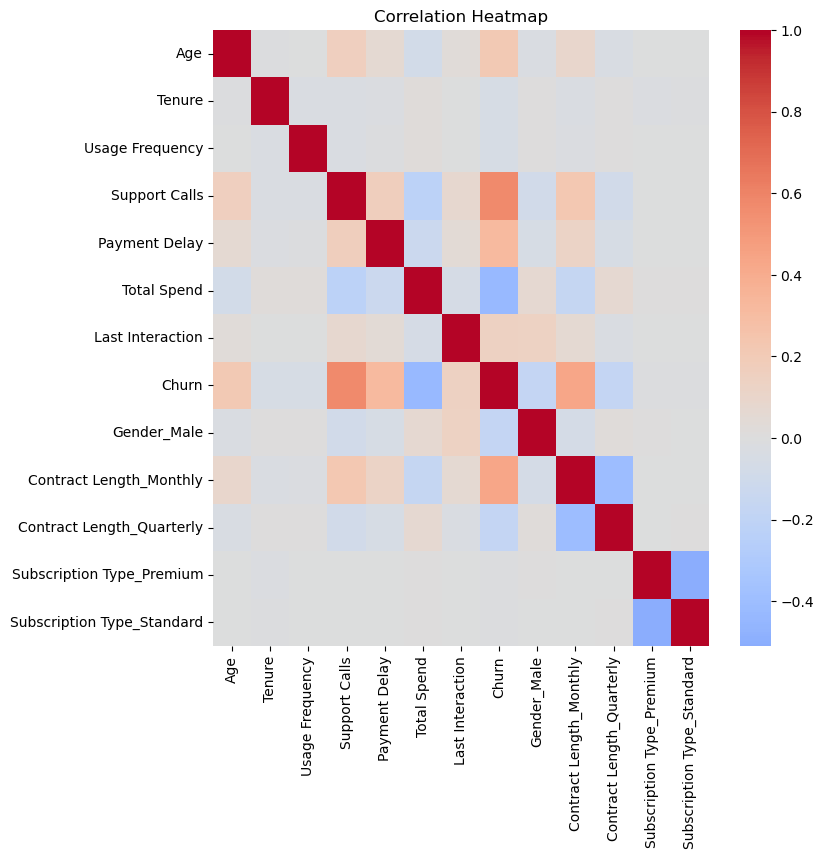

In [47]:
plt.figure(figsize=(5,4))

sns.heatmap(df.corr(),cmap='coolwarm',center=0)

plt.title('Correlation Heatmap')

plt.show()

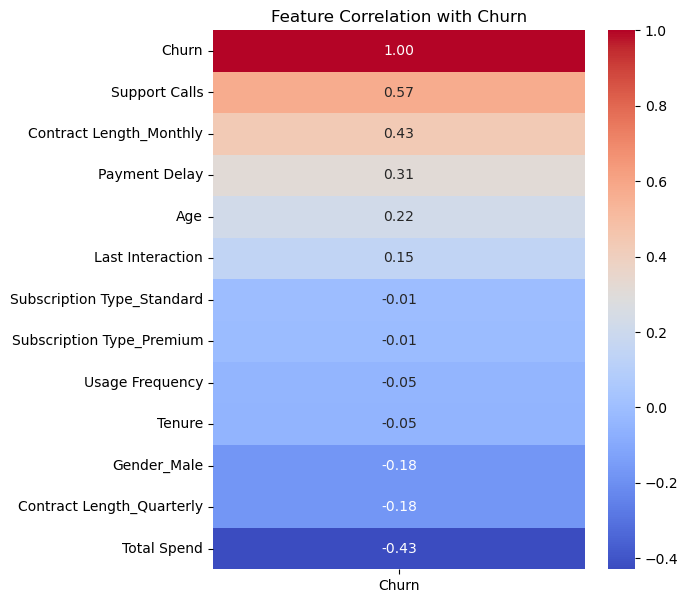

In [48]:
plt.figure(figsize=(6,7))

sns.heatmap(df.corr()[['Churn']].sort_values(by='Churn', ascending=False),annot=True,cmap='coolwarm',fmt='.2f')

plt.title('Feature Correlation with Churn')

plt.show()

# Findings:--
## Strong Features
### -Support Calls~ customers who call more are more likely to churn because of complaints, service issues, dissatisfaction, etc
### -Contract Length_Monthly~ montly contracters had a 100% churn rate 
### -Total Spend~ customers who spend more money churn less
### -Payment Delay~ late paying customers are more likely to churn away
## Moderate Features
### -Age~ older customers churn more
### -Gender_Male~ male customers are more likely to stay 
### -Contract Length_Quarterly~ stay more
### -Last Interaction~ customers with more no. of days without interaction churn more
## Weak Features
### -Tenure~ newer customers churn more
### -Usage Frequency~ customers with less usage freq. churn more
### -Subscription Type~ not a strong predictor

In [49]:
#Spliting data into x-y

In [50]:
X = df.drop('Churn',axis=1)
y = df['Churn']

In [51]:
X.head()

,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction,Gender_Male,Contract Length_Monthly,Contract Length_Quarterly,Subscription Type_Premium,Subscription Type_Standard
0,30.0,39.0,14.0,5.0,18.0,932.0,17.0,0,0,0,0,1
1,65.0,49.0,1.0,10.0,8.0,557.0,6.0,0,1,0,0,0
2,55.0,14.0,4.0,6.0,18.0,185.0,3.0,0,0,1,0,0
3,58.0,38.0,21.0,7.0,7.0,396.0,29.0,1,1,0,0,1
4,23.0,32.0,20.0,5.0,8.0,617.0,20.0,1,1,0,0,0


In [52]:
y.head()

0    1.0
1    1.0
2    1.0
3    1.0
4    1.0
Name: Churn, dtype: float64

In [53]:
#splitting into train and test

In [54]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [55]:
#feature selection using random forest classifier

In [56]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100,random_state=42) #using 100 just for a starting point
rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [ ]:
# feature importance using random forest feature selection

In [57]:
feature_imp = pd.DataFrame({'Feature':X_train.columns,'Importance':rf.feature_importances_}).sort_values(by='Importance',ascending=False)
feature_imp

,Feature,Importance
3,Support Calls,0.294296
5,Total Spend,0.211091
8,Contract Length_Monthly,0.138365
0,Age,0.138001
4,Payment Delay,0.126095
6,Last Interaction,0.036830
7,Gender_Male,0.033689
1,Tenure,0.009869
9,Contract Length_Quarterly,0.005352
2,Usage Frequency,0.004449


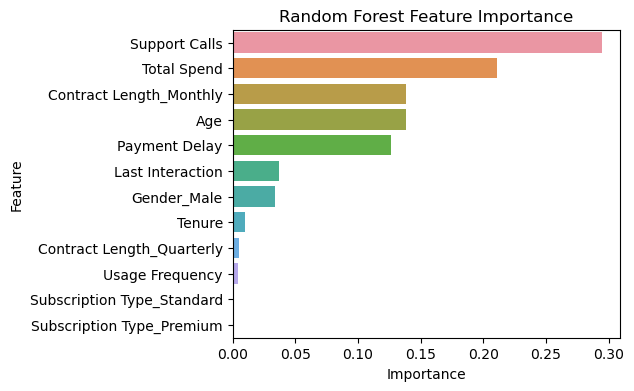

In [58]:
plt.figure(figsize=(5,4))
sns.barplot(x='Importance', y='Feature', data=feature_imp)
plt.title("Random Forest Feature Importance")
plt.show()

### Random Forest feature importance is used to identify the most powerful predictors. Features with no strong contribution, such as Subscription Type and Usage Frequency, will be removed to reduce noise and improve model.

In [59]:
#features to keep
selected_features = [
    'Support Calls',
    'Total Spend',
    'Contract Length_Monthly',
    'Age',
    'Payment Delay',
    'Last Interaction',
    'Gender_Male']

In [60]:
X_train_selected = X_train[selected_features]
X_test_selected = X_test[selected_features]

In [61]:
#Scaling

In [63]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_selected)
X_test_scaled = scaler.transform(X_test_selected)

In [64]:
# Building Models

In [65]:
## Model 1 = Logistic Regression

In [66]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(random_state=42)

lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)

In [67]:
from sklearn.metrics import accuracy_score

accuracy_score(y_test, y_pred_lr)

0.8933047512107705

In [68]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

         0.0       0.86      0.90      0.88     38167
         1.0       0.92      0.89      0.90     50000

    accuracy                           0.89     88167
   macro avg       0.89      0.89      0.89     88167
weighted avg       0.89      0.89      0.89     88167



In [69]:
from sklearn.metrics import confusion_matrix

confusion_matrix(y_test, y_pred_lr)

array([[34482,  3685],
       [ 5722, 44278]], dtype=int64)

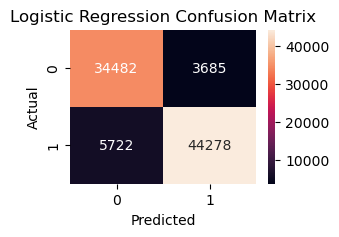

In [70]:
cm = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(3,2))
sns.heatmap(cm, annot=True, fmt='d')

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Logistic Regression Confusion Matrix')

plt.show()

In [71]:
# Model 2 = Decision Tree

In [73]:
from sklearn.tree import DecisionTreeClassifier

In [74]:
dt = DecisionTreeClassifier(max_depth=5,random_state=42)
dt.fit(X_train_selected, y_train)

DecisionTreeClassifier(max_depth=5, random_state=42)

In [75]:
y_pred_dt = dt.predict(X_test_selected)

In [77]:
accuracy_score(y_test, y_pred_dt)

0.9773951705286559

In [80]:
print(classification_report(y_test, y_pred_dt))

              precision    recall  f1-score   support

         0.0       0.95      1.00      0.97     38167
         1.0       1.00      0.96      0.98     50000

    accuracy                           0.98     88167
   macro avg       0.98      0.98      0.98     88167
weighted avg       0.98      0.98      0.98     88167



In [83]:
confusion_matrix(y_test, y_pred_dt)

array([[38164,     3],
       [ 1990, 48010]], dtype=int64)

In [ ]:
#checking for overfitting

In [81]:
print("Train Accuracy:",dt.score(X_train_selected, y_train))
print("Test Accuracy:",dt.score(X_test_selected, y_test))

Train Accuracy: 0.9780528263366084
Test Accuracy: 0.9773951705286559


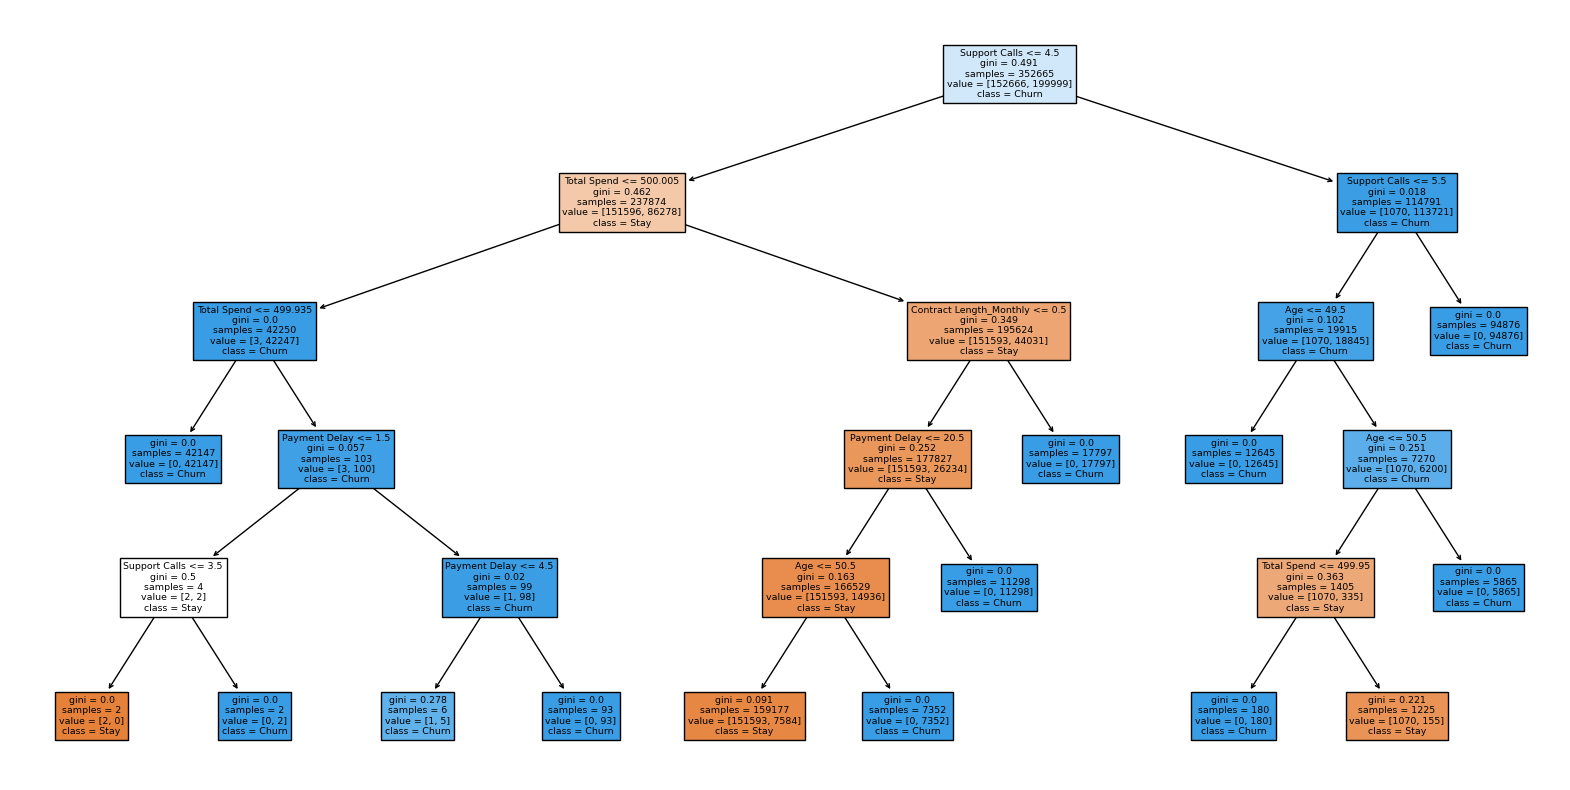

In [85]:
from sklearn.tree import plot_tree

plt.figure(figsize=(20,10))

plot_tree(dt,feature_names=list(X_train_selected.columns),class_names=['Stay','Churn'],filled=True)

plt.show()

In [ ]:
##The dataset contains extremely clear rules.
##The tree can almost perfectly separate churners.
##from the above tree it concludes that on the right side customers who made more than 5 calls churned

In [ ]:
# Model 3 - Random Forest

In [86]:
from sklearn.ensemble import RandomForestClassifier

In [87]:
rf = RandomForestClassifier(n_estimators=100, random_state=42,n_jobs=-1)
rf.fit(X_train_selected, y_train)

RandomForestClassifier(n_jobs=-1, random_state=42)

In [88]:
y_pred_rf = rf.predict(X_test_selected)

In [91]:
accuracy_score(y_test, y_pred_rf)

0.9976748670137353

In [94]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

         0.0       0.99      1.00      1.00     38167
         1.0       1.00      1.00      1.00     50000

    accuracy                           1.00     88167
   macro avg       1.00      1.00      1.00     88167
weighted avg       1.00      1.00      1.00     88167



In [95]:
confusion_matrix(y_test, y_pred_rf)

array([[38164,     3],
       [  202, 49798]], dtype=int64)

In [ ]:
#checking for overfitting

In [97]:
print("Train Accuracy:",rf.score(X_train_selected, y_train))
print("Test Accuracy:",rf.score(X_test_selected, y_test))

Train Accuracy: 0.9999943288956942
Test Accuracy: 0.9976748670137353


In [98]:
feature_imp_rf = pd.DataFrame({
    'Feature': X_train_selected.columns,
    'Importance': rf.feature_importances_
}).sort_values(
    by='Importance',
    ascending=False
)

feature_imp_rf

,Feature,Importance
0,Support Calls,0.305916
1,Total Spend,0.215751
2,Contract Length_Monthly,0.142576
3,Age,0.138684
4,Payment Delay,0.127831
5,Last Interaction,0.038445
6,Gender_Male,0.030797


In [ ]:
#it gives same predictable features as above

In [ ]:
#Roc-Auc

In [99]:
from sklearn.metrics import roc_auc_score

y_prob = rf.predict_proba(X_test_selected)[:,1]

auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC:", auc)

ROC-AUC: 0.9980298786910157


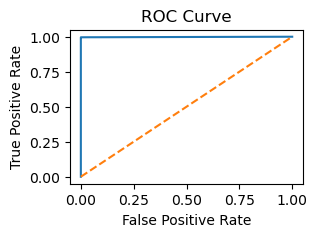

In [102]:
#roc curve

from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(3,2))
plt.plot(fpr, tpr)
plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.show()

In [ ]:
#roc-auc curve evaluated results on different thressholds and gave excellent results. model is highly capable of distinguishing between churned customers and retained customers

In [ ]:
#Cross-validation

In [103]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(rf, X_train_selected, y_train, cv = 5, scoring = 'accuracy')
print(cv_scores)
print('Average CV Accuracy:',cv_scores.mean())

[0.99746218 0.99729205 0.99720698 0.99763231 0.99741965]
Average CV Accuracy: 0.99740263422795


In [ ]:
#Model is stable
#Model is not dependent on one split
#Model generalizes well and doesn't overfit

In [ ]:
#randomisedsearchcv -- hyper parameter tuning

In [104]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'n_estimators':[100,200,300], # no. of trees
    'max_depth':[5,10,15,None], # depth of tree
    'min_samples_split':[2,5,10], # no. of samples in a split
    'min_samples_leaf':[1,2,4]} # no. of records in a final leaf

random_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_distributions=param_dist,
    n_iter=10, #no. of combinations
    cv=3, # 3 fold cross-val
    scoring='accuracy', #accuracy
    random_state=42,
    n_jobs=-1) #use all CPU cores

random_search.fit(X_train_selected, y_train)

print("Best Parameters:")
print(random_search.best_params_)

print("\nBest CV Score:")
print(random_search.best_score_)

Best Parameters:
{'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_depth': None}

Best CV Score:
0.9974224830930202


In [ ]:
# Best-tuned model 

In [105]:
best_rf = random_search.best_estimator_
best_rf.fit(X_train_selected, y_train)

RandomForestClassifier(min_samples_leaf=2, min_samples_split=5,
                       n_estimators=300, random_state=42)

In [106]:
y_pred_best = best_rf.predict(X_test_selected)

In [107]:
print("Accuracy:",accuracy_score(y_test, y_pred_best))

Accuracy: 0.9976748670137353


In [ ]:
# comparision table

In [108]:
results = pd.DataFrame({'Model':['Logistic Regression','Decision Tree','Random Forest'],
                       'Accuracy':[0.89,0.97,0.99]})
results['Accuracy %'] = results['Accuracy']*100
results

,Model,Accuracy,Accuracy %
0,Logistic Regression,0.89,89.0
1,Decision Tree,0.97,97.0
2,Random Forest,0.99,99.0


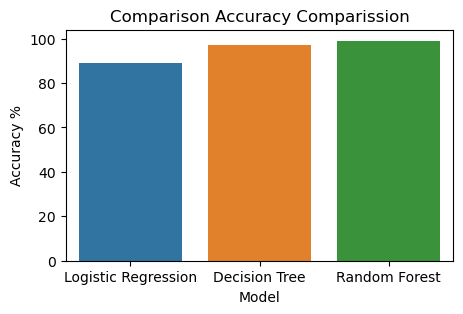

In [112]:
plt.figure(figsize=(5,3))
sns.barplot(x='Model', y='Accuracy %', data=results)
plt.title('Comparison Accuracy Comparission')
plt.xlabel('Model')
plt.ylabel('Accuracy %')
plt.show()

### Three models were evaluated for churn prediction. Logistic Regression: 89% accuracy, Decision Tree: 97.74% accuracy, and Random Forest: 99.77% accuracy. Random Forest gave the best overall performance and was selected as the final model.

In [ ]:
#saving the model

In [113]:
import joblib

joblib.dump(best_rf,'customer_churn_rf.pkl')

['customer_churn_rf.pkl']

In [114]:
loaded_model = joblib.load('customer_churn_rf.pkl') #verifying loading model

loaded_model.predict(X_test_selected[:5])

array([1., 0., 1., 0., 1.])

In [115]:
results.to_csv('model_comparison.csv',index=False)

In [116]:
X_train_selected.columns.tolist()

['Support Calls',
 'Total Spend',
 'Contract Length_Monthly',
 'Age',
 'Payment Delay',
 'Last Interaction',
 'Gender_Male']

# ~~~~~~~~~~~~~Business Recommendations~~~~~~~~~~~~~


### --> Customers making frequent support calls should be proactively contacted, as Support Calls was the strongest predictor of churn.
### --> Customers on monthly contracts should be encouraged to switch to quarterly or annual plans through discounts and loyalty programs.
### --> Customers with payment delays should receive timely reminders and personalized payment assistance.
### --> Low-spending customers should be targeted with retention campaigns and special offers.
### --> Customers showing long periods of inactivity should be re-engaged through personalized marketing strategies.